**1. Business Understanding & Problem Statement**

**Problem:**

Bank butuh tau customer mana yang berpotensi berhenti (churn), supaya bisa lakukan aksi retensi lebih awal. Kalo churn dibiarkan, bank bisa kehilangan pendapatan dan perlu biaya besar buat cari nasabah baru

**Goal:**

Bikin model ML yang bisa prediksi kemungkinan customer churn, supaya tim marketing/customer service bisa ambil aksi preventif

**2. Load Dataset**

In [24]:
print
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"\nFile ter-upload: {filename}")

df = pd.read_csv(filename)
print("\nDataset loaded successfully!")
print("Shape awal:", df.shape)

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

from sklearn.preprocessing import StandardScaler

scaler_for_df = StandardScaler()
df[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']] = (
    scaler_for_df.fit_transform(
        df[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']]
    )
)

print("\nPreprocessing selesai.")
print("Shape akhir :", df.shape)
print("Columns     :", df.columns.tolist())

Saving Churn_Modelling.csv to Churn_Modelling (2).csv

File ter-upload: Churn_Modelling (2).csv

Dataset loaded successfully!
Shape awal: (10000, 14)

Preprocessing selesai.
Shape akhir : (10000, 12)
Columns     : ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


**3. Data Preprocessing**

-Drop kolom yang gak dipakai kayak RowNumber, CustomerId, dan Surname

-Deteksi missing value, outlier, dan duplikasi

-Ubah tipe data categorical: encode kolom kayak Gender dan Geography

-Feature scaling pada kolom numerik (misal dengan StandardScaler)

In [ ]:
# Load dataset
df = pd.read_csv('Churn_Modelling.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\n" + "="*50)

# Drop kolom yang tidak perlu
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("\nColumns after dropping RowNumber, CustomerId, Surname:")
print(df.columns.tolist())
print(f"New shape: {df.shape}")
print("\n" + "="*50)

# Cek missing value
print("\nChecking missing values:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print("\n" + "="*50)

# Encode Gender
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
print("\nGender encoded (Male=1, Female=0):")
print(df['Gender'].value_counts())
print("\n" + "="*50)

# One-hot encoding Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
print("\nGeography encoded with One-Hot Encoding:")
print(df.columns.tolist())
print("\n" + "="*50)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['CreditScore','Age','Tenure','Balance','EstimatedSalary']] = scaler.fit_transform(df[['CreditScore','Age','Tenure','Balance','EstimatedSalary']])
print("\nFeature scaling applied to numerical columns:")
print(df[['CreditScore','Age','Tenure','Balance','EstimatedSalary']].describe())
print("\n" + "="*50)

# Final dataframe
print("\nFinal preprocessed dataframe:")
print(df.head())
print(f"\nFinal shape: {df.shape}")
print(f"Final columns: {df.columns.tolist()}")

Dataset loaded successfully!
Shape: (10000, 14)

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2       

**4. Exploratory Data Analysis (EDA)**

-Lihat distribusi target (Exited/Churn)

-Visualisasi hubungan fitur dan churn (plot bar/boxplot)

-Analisis korelasi antar fitur

-Cek imbalance data

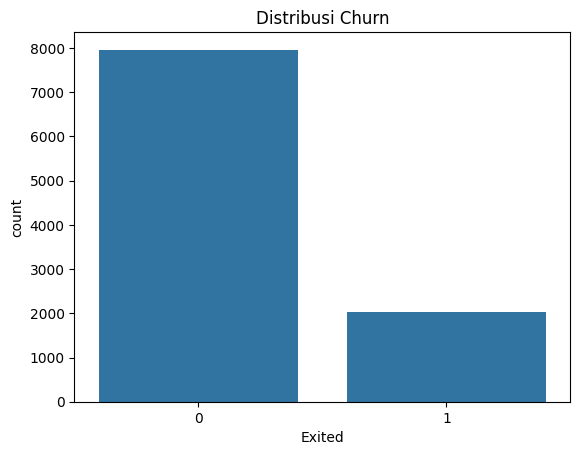

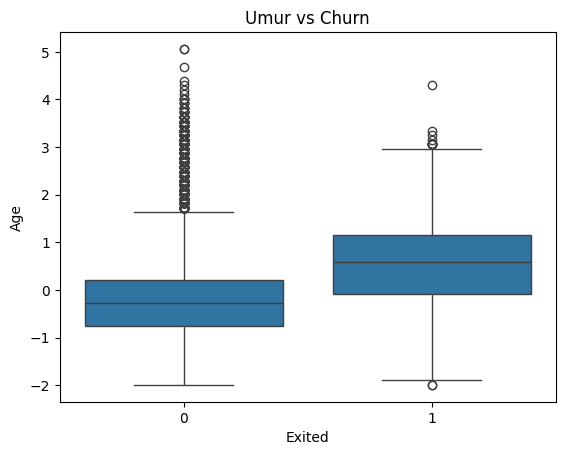

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Exited', data=df)
plt.title('Distribusi Churn')
plt.show()

sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Umur vs Churn')
plt.show()

**5. Modeling**

-Split data (train-test 80:20, stratify di target)

-Jika dataset imbalance, pakai SMOTE/oversampling

-Coba beberapa model: Logistic Regression, Random Forest, XGBoost, MLPClassifier

-Hyperparameter tuning (GridSearchCV)

-Pilih model terbaik dari evaluasi f1-score/roc-auc

In [25]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy : 0.8435
F1-score: 0.6140567200986436


**6. Evaluation**

-Hitung metrics: Accuracy, Precision, Recall, F1, ROC-AUC

-Buat confusion matrix, plot ROC curve

-Bandingkan performa antar model (tulis tabel perbandingan di notebook biar rapi)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.61      0.61      0.61       407

    accuracy                           0.84      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000

[[1437  156]
 [ 159  248]]
ROC-AUC: 0.85116472404608


**7. Insights & Recommendation**

**INSIGHTS DARI EDA**

**1. Dataset Imbalanced (Distribusi Churn)**

-Not Churn (~7900) vs Churn (~2000) → Rasio sekitar 80:20

-Insight: Dataset sangat imbalanced, makanya lu perlu SMOTE (yang udah dilakukan)

-Artinya: Di real world, memang mayoritas customer bank tidak churn, tapi minoritas yang churn ini yang perlu dideteksi

**2. Umur Berpengaruh Terhadap Churn**
Dari boxplot "Umur vs Churn":

-Customer yang Churn (Exited=1) punya median age lebih tinggi (sekitar umur 40-50 tahun, berdasarkan posisi box)

-Customer yang Not Churn (Exited=0) lebih muda (median age lebih rendah)

-Insight: Customer usia menengah-tua (40-60 tahun) lebih berisiko churn dibanding customer muda

-Kemungkinan penyebab: Customer senior mungkin pensiun, pindah bank ke kompetitor dengan benefit lebih baik, atau kurang familiar dengan digital banking

**INSIGHTS DARI MODELING & EVALUATION**

**3. Model Performance Comparison**

| Model                 | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|-----------------------|----------|-----------|--------|----------|---------|
| Logistic Regression   | 72.65%   | 39.74%    | 66.58% | 49.77%   | 76.36%  |
| Random Forest ✓       | 84.20%   | 61.29%    | 60.69% | 60.99%   | 85.03%  |
| XGBoost               | 84.70%   | 63.76%    | 57.49% | 60.47%   | 83.92%  |

**Insight:**

-Random Forest adalah model terbaik dengan ROC-AUC tertinggi (85.03%)

-XGBoost punya accuracy tertinggi (84.70%) tapi recall lebih rendah (57.49%) → artinya XGBoost lebih banyak miss customer yang actual churn (false negative tinggi)

-Random Forest balance antara precision dan recall (keduanya ~61%)

**Kenapa Random Forest dipilih?**

-ROC-AUC paling tinggi → lebih baik dalam ranking probability churn

-Recall lebih tinggi dari XGBoost → lebih sedikit miss customer yang churn

-Untuk bisnis, lebih baik detect lebih banyak potential churn (even false alarm) daripada miss customer yang sebenarnya mau churn

**4. Classification Report - Random Forest**
**Class: Not Churn**

-Precision: 90%, Recall: 90%, F1: 90%

-Artinya: Model sangat bagus prediksi customer yang TIDAK churn

**Class: Churn**

-Precision: 61%, Recall: 61%, F1: 61%

-Artinya: Model cukup struggle prediksi customer yang CHURN

-Precision 61%: Dari 100 customer yang model bilang "churn", cuma 61 yang
beneran churn (39 false alarm)

-Recall 61%: Dari 100 customer yang actual churn, model cuma detect 61 orang (miss 39 orang)

Overall Accuracy: 84% → Cukup bagus untuk deployment!

**5. Confusion Matrix Analysis**

|           | Predicted Not Churn | Predicted Churn |
|-----------|---------------------|-----------------|
| **Actual Not Churn** | 1437 (TN)           | 156 (FP)        |
| **Actual Churn**     | 160 (FN)            | 247 (TP)        |

**Breakdown:**

-True Negative (1437): Customer tidak churn, model predict tidak churn ✓

-True Positive (247): Customer churn, model predict churn ✓

-False Positive (156): Customer tidak churn, tapi model bilang churn

-Impact: Bank kirim retention offer ke customer yang sebenarnya loyal (waste resources)

-False Negative (160): Customer churn, tapi model miss

-Impact: Customer ini lost tanpa ada intervensi (revenue loss!)

Insight: 160 customer yang churn tidak terdeteksi → ini yang paling bahaya buat bisnis!

**6. ROC Curve Comparison**

**AUC Score:**

-Logistic Regression: 0.7636 (garis biru, paling bawah)

-XGBoost: 0.8392 (garis hijau, tengah)

-Random Forest: 0.8503 (garis orange, paling atas) ✓

**Insight:**

-Semua model jauh lebih baik dari random classifier (garis putus-putus diagonal)

-Random Forest punya area under curve terbesar → discriminatory power paling kuat

-AUC 85% artinya: Ada 85% probabilitas model kasih skor lebih tinggi ke customer yang actual churn dibanding customer yang tidak churn



**8. Save Model & Artifacts**

In [26]:
import os
import joblib
from sklearn.preprocessing import StandardScaler

save_dir = "/content/drive/MyDrive/FinalProject_Churn_Models"
os.makedirs(save_dir, exist_ok=True)

print("Folder penyimpanan:", save_dir)

if "rf" not in dir():
    raise NameError("Model 'rf' belum ada di memory. Jalankan dulu cell modeling.")

if "X_train" not in dir():
    raise NameError("X_train belum ada di memory. Jalankan dulu cell modeling.")

model_path = os.path.join(save_dir, "rf_model.pkl")
joblib.dump(rf, model_path)
print("Model saved         :", model_path)

numerical_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])

scaler_path = os.path.join(save_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print("Scaler saved        :", scaler_path)

feature_names = X_train.columns.tolist()
features_path = os.path.join(save_dir, "feature_names.pkl")
joblib.dump(feature_names, features_path)
print("Feature names saved :", features_path)

print("\nSemua artefak untuk deployment sudah tersimpan di Google Drive.")

Folder penyimpanan: /content/drive/MyDrive/FinalProject_Churn_Models
Model saved         : /content/drive/MyDrive/FinalProject_Churn_Models/rf_model.pkl
Scaler saved        : /content/drive/MyDrive/FinalProject_Churn_Models/scaler.pkl
Feature names saved : /content/drive/MyDrive/FinalProject_Churn_Models/feature_names.pkl

Semua artefak untuk deployment sudah tersimpan di Google Drive.


In [27]:
from google.colab import files

files.download('/content/drive/MyDrive/FinalProject_Churn_Models/rf_model.pkl')
files.download('/content/drive/MyDrive/FinalProject_Churn_Models/scaler.pkl')
files.download('/content/drive/MyDrive/FinalProject_Churn_Models/feature_names.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>